In [5]:
import os
from pathlib import Path

project_path = Path.cwd()

print(project_path)

/Users/prithvi/Documents/Projects/PSTAT-134-Final-Project/notebooks


In [6]:
import sys
!{sys.executable} -m pip install nltk

In [7]:
import pandas as pd
import numpy as np
import re
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prithvi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/prithvi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/prithvi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/prithvi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
import os
print(os.getcwd())

/Users/prithvi/Documents/Projects/PSTAT-134-Final-Project/notebooks


In [9]:
df = pd.read_csv("../data/cleaned/reddit_cleaned.csv")

In [10]:

print(f"Loaded {len(df)} posts")
df.head(3)

Loaded 755 posts


,id,title,selftext,upvote_ratio,num_comments,is_self,edited,created_utc,subreddit,full_text
0,1nimpmu,DOJ Deletes Study Showing Domestic Terrorists ...,NaN,0.88,2681,False,False,1.758041e+09,technology,doj deletes study showing domestic terrorist o...
1,1nlju03,Disney+ cancellation page crashes as customers...,NaN,0.89,3300,False,False,1.758327e+09,technology,disney cancellation page crash customer rush q...
2,1nkl8b0,"Yes, Jimmy Kimmel’s suspension was government ...",NaN,0.81,3102,False,False,1.758232e+09,technology,yes jimmy kimmels suspension government censor...


In [11]:
# Fill empty selftext with empty string
df["selftext"] = df["selftext"].fillna("")

# Combine title and body into one column
df["full_text"] = df["title"] + " " + df["selftext"]

print("Sample full_text:")
print(df["full_text"][0])

# Here we are combining the title and the body,as some posts have no body text so we fill those with empty string first, then combine title + body into one single full_text column. This is the main text we'll use for all NLP analysis.

Sample full_text:
DOJ Deletes Study Showing Domestic Terrorists Are Most Often Right Wing 


In [12]:
def clean_text(text):
    text = text.lower()                        # make everything lowercase
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)       # remove numbers and special chars
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

df["full_text"] = df["full_text"].apply(clean_text)
print("Sample cleaned text:")
print(df["full_text"][0])

# cleaning the data overall

Sample cleaned text:
doj deletes study showing domestic terrorists are most often right wing


In [13]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize each word
    return " ".join(tokens)

df["full_text"] = df["full_text"].apply(preprocess)
print("Sample after stopwords + lemmatization:")
print(df["full_text"][0])

# removing the stop words and lemmatization

Sample after stopwords + lemmatization:
doj deletes study showing domestic terrorist often right wing


In [14]:
before = len(df)
df = df[df["full_text"].apply(lambda x: len(x.split()) >= 3)]
after = len(df)

print(f"Rows before: {before}")
print(f"Rows after dropping short posts: {after}")
print(f"Rows dropped: {before - after}")
print(f"\nPosts per subreddit:")
print(df["subreddit"].value_counts())

Rows before: 755
Rows after dropping short posts: 755
Rows dropped: 0

Posts per subreddit:
subreddit
technology         200
MachineLearning    200
artificial         188
singularity        167
Name: count, dtype: int64


In [18]:
df.to_csv("../data/cleaned/reddit_cleaned.csv", index=False)
print(f"Saved {len(df)} cleaned posts to data/cleaned/reddit_cleaned.csv")

Saved 755 cleaned posts to data/cleaned/reddit_cleaned.csv


## Exploratory Data Analysis Visualizations

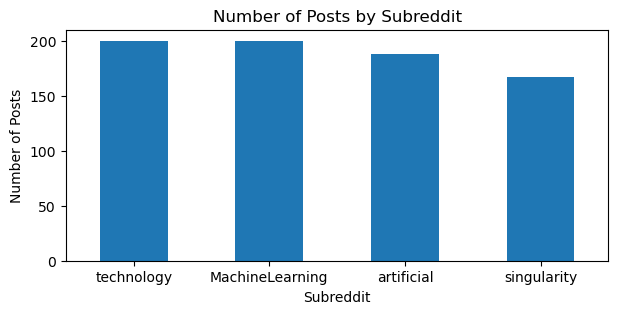

In [25]:
#posts per sub reddit

import matplotlib.pyplot as plt

subreddit_counts = df["subreddit"].value_counts()

plt.figure(figsize=(7, 3))
subreddit_counts.plot(kind="bar")

plt.title("Number of Posts by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts")
plt.xticks(rotation=360)

plt.show()

<Figure size 700x300 with 0 Axes>

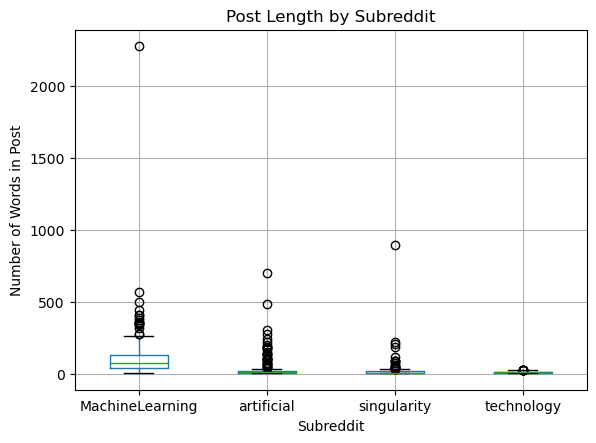

In [28]:
#post length

import matplotlib.pyplot as plt

#new column to visualize how many words are in each clearned post

df["post_length"] = df["full_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 3))


df.boxplot(
    column="post_length",
    by="subreddit"
)

plt.title("Post Length by Subreddit")
plt.suptitle("")
plt.xlabel("Subreddit")
plt.ylabel("Number of Words in Post")

plt.xticks(rotation=360)

plt.show()

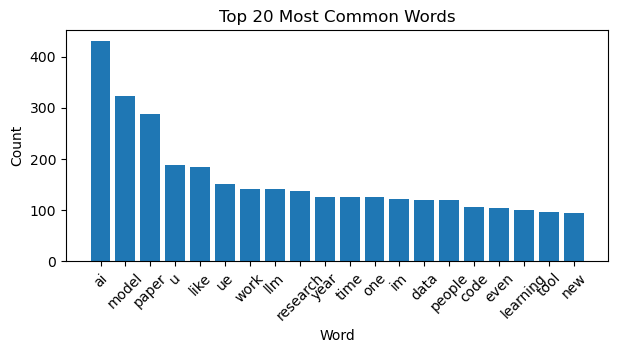

In [30]:
#top words

from collections import Counter

all_words = " ".join(df["full_text"].fillna("")).lower().split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

plt.figure(figsize=(7, 3))
plt.bar(words, counts)

plt.title("Top 20 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

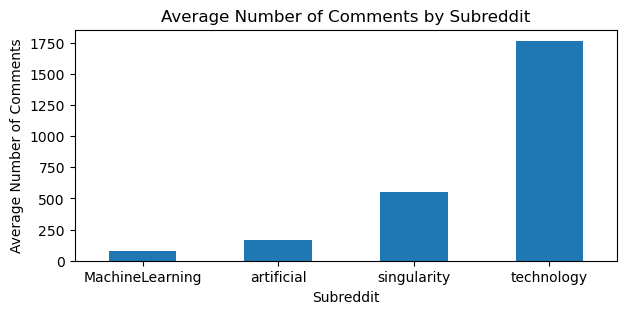

In [33]:
#average comments by subreddits

avg_comments = df.groupby("subreddit")["num_comments"].mean()

plt.figure(figsize=(7, 3))
avg_comments.plot(kind="bar")

plt.title("Average Number of Comments by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Average Number of Comments")
plt.xticks(rotation=360)

plt.show()


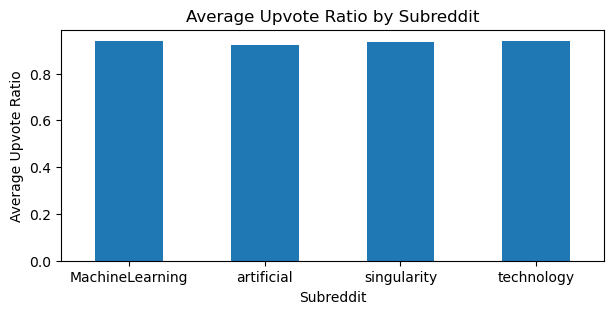

In [35]:
#upvote ratio
avg_upvote_ratio = df.groupby("subreddit")["upvote_ratio"].mean()

plt.figure(figsize=(7, 3))
avg_upvote_ratio.plot(kind="bar")

plt.title("Average Upvote Ratio by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Average Upvote Ratio")
plt.xticks(rotation=360)

plt.show()